<a href="https://colab.research.google.com/github/XTruong1511/TH_DeepLaening/blob/main/TH_Deep_B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

bài tập CNN

bài tập demo

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [4]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)
(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


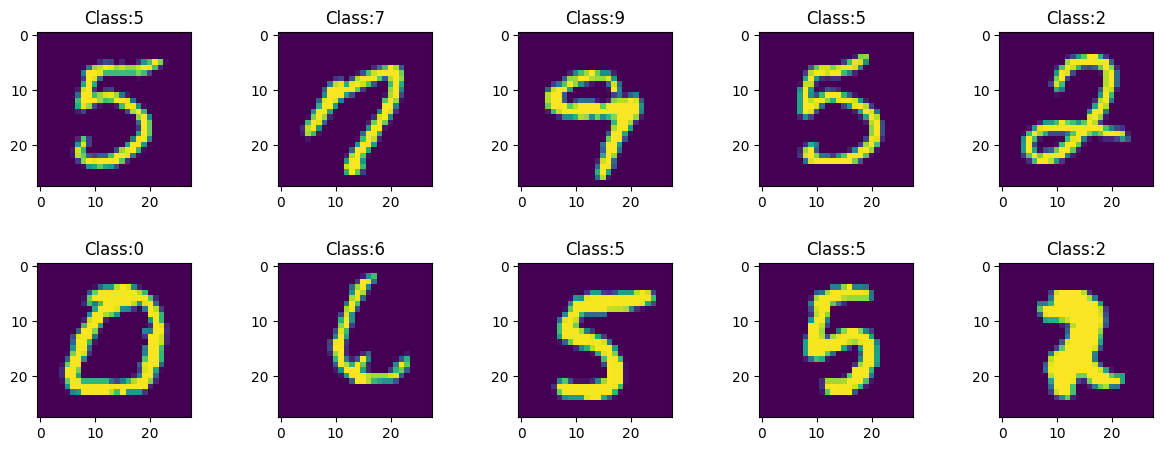

In [5]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [7]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.9145 - loss: 0.2988 - val_accuracy: 0.9720 - val_loss: 0.0967
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9738 - loss: 0.0855 - val_accuracy: 0.9779 - val_loss: 0.0738
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9812 - loss: 0.0595 - val_accuracy: 0.9849 - val_loss: 0.0481
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9848 - loss: 0.0457 - val_accuracy: 0.9806 - val_loss: 0.0616
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9764 - val_loss: 0.0772
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9906 - loss: 0.0276 - val_accuracy: 0.9853 - val_loss: 0.0504
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9923 - loss: 0.0231 - val_accuracy: 0.9868 - val_loss: 0.0464
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9941 - loss: 0.0169 - 

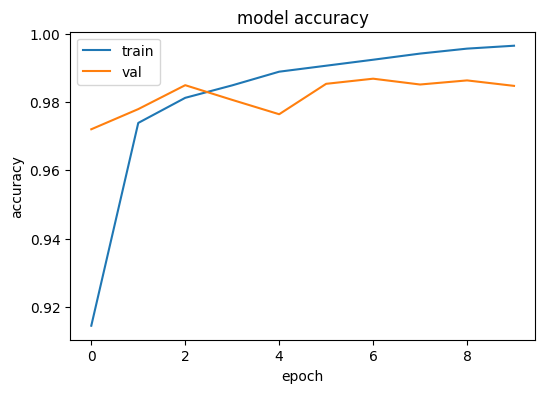

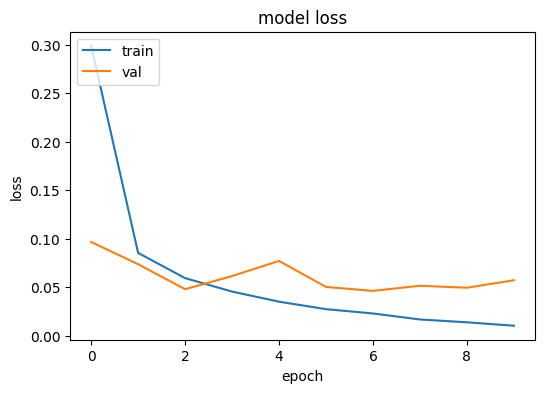

In [8]:
# 1. Biên dịch mô hình
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 2. Huấn luyện mô hình và lưu lịch sử vào biến model_fit
model_fit = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# 3. Vẽ biểu đồ

# model accuracy
plt.figure(figsize=(6, 4))
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#model loss
plt.figure(figsize=(6, 4))
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [9]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 10ms/step - accuracy: 0.9847 - loss: 0.0573
Test loss: 0.05733532831072807
Test accuracy: 0.984698474407196


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
[[2.66751043e-09 6.62768289e-05 9.99933720e-01 2.41116371e-09
  4.16024996e-20 8.09192743e-18 1.07998377e-09 3.91258250e-18
  1.34661535e-08 2.48876917e-21]]
2 2


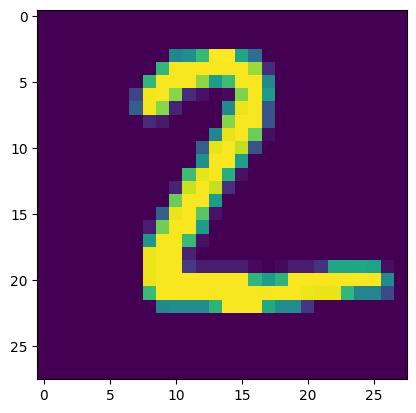

In [10]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [12]:
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[2.5523306e-08 9.9999166e-01 1.6017673e-06 1.0411577e-09 3.5817629e-06
  1.0419807e-08 1.6509139e-07 2.4180335e-06 5.4460861e-07 1.5185841e-09]]
1 1


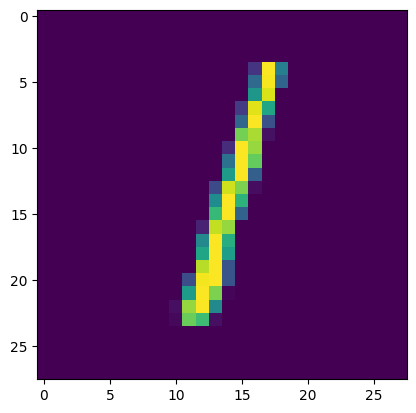

In [13]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

Bài tập 1. Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4439 - loss: 1.5339 - val_accuracy: 0.5530 - val_loss: 1.2329
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5859 - loss: 1.1637 - val_accuracy: 0.6159 - val_loss: 1.0721
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6490 - loss: 1.0012 - val_accuracy: 0.6484 - val_loss: 1.0030
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6827 - loss: 0.9039 - val_accuracy: 0.6785 - val_loss: 0.9183
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7090 - loss: 0.8295 - val_accuracy: 0.6586 - val_loss: 0.9847
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7283 - loss: 0.7760 - val_accuracy: 0.6963 - val_loss: 0.8611
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7437 - loss: 0.7278 - val_accuracy: 0.7049 - val_loss: 0.8653
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━

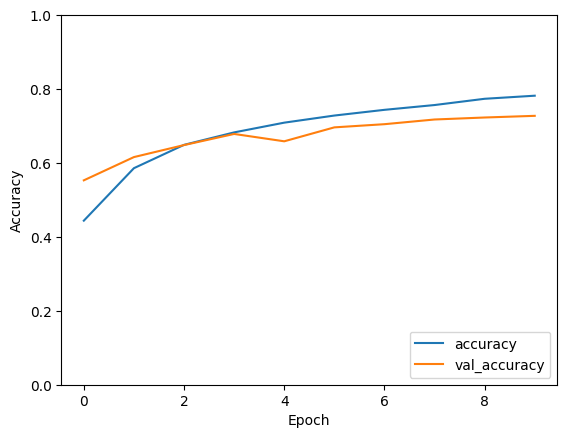

In [41]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Sequential, Input
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải và tiền xử lý dữ liệu
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# 2. Xây dựng mô hình
model_cifar = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cifar.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Huấn luyện mô hình (10 epochs)
history_cifar = model_cifar.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# 4. Hiển thị kết quả huấn luyện
plt.plot(history_cifar.history['accuracy'], label='accuracy')
plt.plot(history_cifar.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

Saving concho.jpg to concho (3).jpg


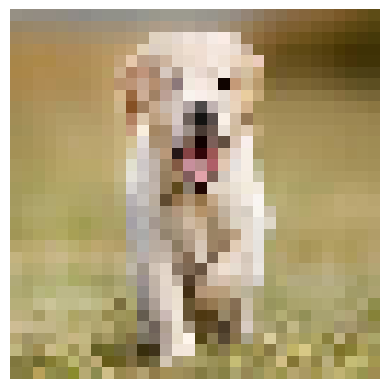

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
Ảnh này có khả năng cao nhất là: dog (60.62%)


In [43]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(32, 32))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    if 'model_cifar' in globals():
        predictions = model_cifar.predict(x)
        score = tf.nn.softmax(predictions[0])
        print(f"Ảnh này có khả năng cao nhất là: {class_names[np.argmax(predictions)]} ({100 * np.max(predictions):.2f}%)")
    else:
        print("Lỗi: Không tìm thấy biến model_cifar trong hệ thống.")

Bài tập 2. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog. Dữ liệu do giảng viên cung cấp

In [4]:
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input

# 1. Tải và chuẩn bị dữ liệu
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
data_dir = os.path.join(path, 'PetImages')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# 2. Định nghĩa mô hình
model_dogcat = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dogcat.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Huấn luyện mô hình
print("Bắt đầu huấn luyện mô hình...")
history_dogcat = model_dogcat.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Bắt đầu huấn luyện mô hình...
Epoch 1/10
220/625 ━━━━━━━━━━━━━━━━━━━━ 1:43 255ms/step - accuracy: 0.5518 - loss: 0.6823

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 400ms/step - accuracy: 0.6701 - loss: 0.5954 - val_accuracy: 0.7511 - val_loss: 0.5022
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 225ms/step - accuracy: 0.7652 - loss: 0.4852 - val_accuracy: 0.7667 - val_loss: 0.4741
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 222ms/step - accuracy: 0.7991 - loss: 0.4276 - val_accuracy: 0.7959 - val_loss: 0.4289
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 220ms/step - accuracy: 0.8282 - loss: 0.3847 - val_accuracy: 0.8371 - val_loss: 0.3663
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 226ms/step - accuracy: 0.8436 - loss: 0.3558 - val_accuracy: 0.8245 - val_loss: 0.3996
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 226ms/step - accuracy: 0.8542 - loss: 0.3323 - val_accuracy: 0.8411 - val_loss: 0.3512
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 224ms/step - accuracy: 0.8680 - loss: 0.3102 - val_accuracy: 0.8425 - val_loss: 0.3534
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.8756 - loss: 0.28

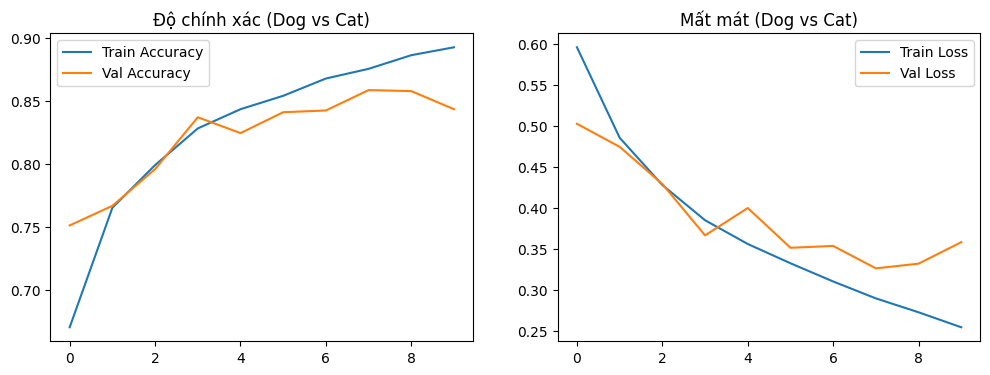

In [7]:
# 5. Hiển thị kết quả
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dogcat.history['accuracy'], label='Train Accuracy')
plt.plot(history_dogcat.history['val_accuracy'], label='Val Accuracy')
plt.title('Độ chính xác (Dog vs Cat)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dogcat.history['loss'], label='Train Loss')
plt.plot(history_dogcat.history['val_loss'], label='Val Loss')
plt.title('Mất mát (Dog vs Cat)')
plt.legend()

plt.show()

Saving concho.jpg to concho (2).jpg


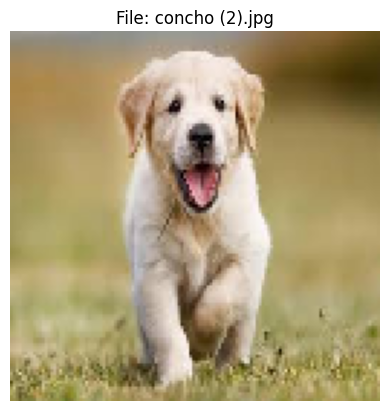

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Kết quả: Dog (99.69%)


In [42]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(128, 128))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    plt.imshow(img)
    plt.title(f"File: {fn}")
    plt.axis('off')
    plt.show()

    if 'model_dogcat' in globals():
        pred = model_dogcat.predict(x)
        result = "Dog" if pred[0][0] > 0.5 else "Cat"
        confidence = pred[0][0] if pred[0][0] > 0.5 else 1 - pred[0][0]
        print(f"Kết quả: {result} ({confidence*100:.2f}%)")
    else:
        print("Lỗi: model_dogcat chưa được huấn luyện!")

Bài tập 3. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST.

In [5]:
from tensorflow.keras.datasets import fashion_mnist

# 1. Tải dữ liệu Fashion-MNIST
(X_train_f, y_train_f), (X_test_f, y_test_f) = fashion_mnist.load_data()

# 2. Tiền xử lý dữ liệu
X_train_f = X_train_f.astype('float32') / 255.0
X_test_f = X_test_f.astype('float32') / 255.0
X_train_f = X_train_f.reshape(-1, 28, 28, 1)
X_test_f = X_test_f.reshape(-1, 28, 28, 1)

# Chuyển nhãn sang dạng one-hot encoding
y_train_f = tf.keras.utils.to_categorical(y_train_f, 10)
y_test_f = tf.keras.utils.to_categorical(y_test_f, 10)

print('Kích thước tập huấn luyện:', X_train_f.shape)

# 3. Xây dựng mô hình
model_fashion = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_fashion.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Huấn luyện mô hình
history_fashion = model_fashion.fit(
    X_train_f, y_train_f,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_f, y_test_f)
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28, 1)
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8231 - loss: 0.4860 - val_accuracy: 0.8611 - val_loss: 0.4021
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8841 - loss: 0.3197 - val_accuracy: 0.8851 - val_loss: 0.3264
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8996 - loss: 0.2725 - val_accuracy: 0.8904 - val_loss: 0.3022
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9100 - loss: 0.2423 - val_accuracy: 0.8953 - val_loss: 0.2906
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9196 - loss: 0.2181 - val_accuracy: 0.9101 - val_loss: 0.2477
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9289 - loss: 0.1931 - val_accuracy: 0.9067 - val_loss: 0.26

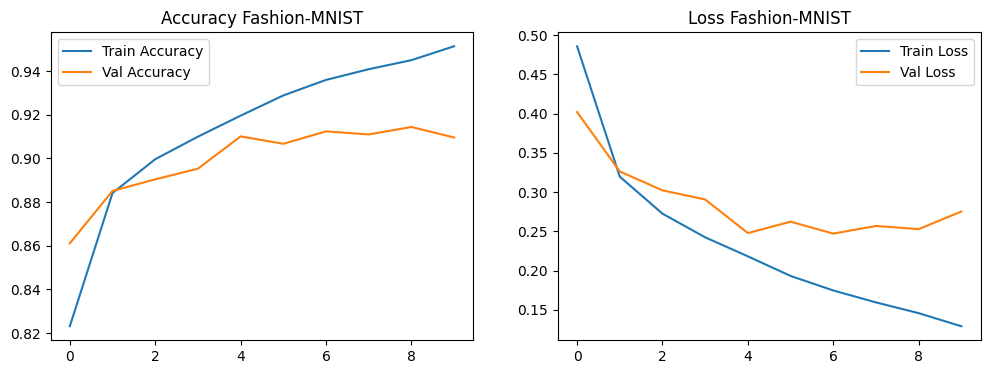

In [6]:
# 5. Hiển thị kết quả huấn luyện Fashion-MNIST
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fashion.history['accuracy'], label='Train Accuracy')
plt.plot(history_fashion.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Fashion-MNIST')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fashion.history['loss'], label='Train Loss')
plt.plot(history_fashion.history['val_loss'], label='Val Loss')
plt.title('Loss Fashion-MNIST')
plt.legend()

plt.show()

Saving ao.webp to ao (1).webp


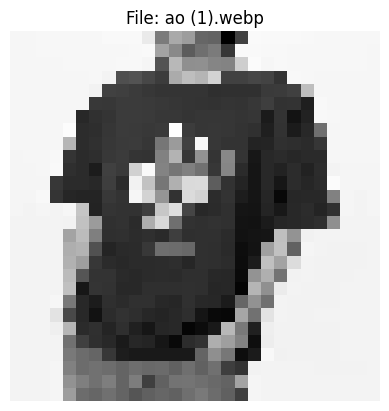

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Kết quả: Pullover (76.29%)


In [44]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

uploaded = files.upload()

class_names_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    plt.imshow(img, cmap='gray')
    plt.title(f"File: {fn}")
    plt.axis('off')
    plt.show()

    if 'model_fashion' in globals():
        preds = model_fashion.predict(x)
        result = class_names_fashion[np.argmax(preds)]
        print(f"Kết quả: {result} ({np.max(preds)*100:.2f}%)")
    else:
        print("Lỗi: model_fashion chưa được huấn luyện!")

bài tập 4. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh khuôn mặt {Nam, Nữ}

In [20]:
import os
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Tải và chuẩn bị dữ liệu Nam/Nữ
gender_path = kagglehub.dataset_download('ashwingupta3012/male-and-female-faces-dataset')

gender_data_dir = os.path.join(gender_path, 'Male and Female face dataset')

gender_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

gender_train_generator = gender_train_datagen.flow_from_directory(
    gender_data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

gender_val_generator = gender_train_datagen.flow_from_directory(
    gender_data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print(f'Các lớp: {gender_train_generator.class_indices}')

Using Colab cache for faster access to the 'male-and-female-faces-dataset' dataset.
Found 4335 images belonging to 2 classes.
Found 1083 images belonging to 2 classes.
Các lớp: {'Female Faces': 0, 'Male Faces': 1}


In [49]:
from tensorflow.keras.layers import Dropout

# 2. Xây dựng mô hình CNN cải tiến cho Gender Classification
model_gender = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gender.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Bắt đầu huấn luyện ... ")
history_gender = model_gender.fit(
    gender_train_generator,
    epochs=10,
    validation_data=gender_val_generator
)

Epoch 1/10
 25/136 ━━━━━━━━━━━━━━━━━━━━ 1:30 816ms/step - accuracy: 0.5273 - loss: 0.7697

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


136/136 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6067 - loss: 0.6573 - val_accuracy: 0.6667 - val_loss: 0.6069
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 130s 954ms/step - accuracy: 0.6784 - loss: 0.5964 - val_accuracy: 0.6925 - val_loss: 0.5913
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 130s 955ms/step - accuracy: 0.6950 - loss: 0.5666 - val_accuracy: 0.7590 - val_loss: 0.5152
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 130s 957ms/step - accuracy: 0.7596 - loss: 0.4957 - val_accuracy: 0.7581 - val_loss: 0.4959
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 127s 934ms/step - accuracy: 0.7899 - loss: 0.4631 - val_accuracy: 0.7904 - val_loss: 0.4558
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 127s 939ms/step - accuracy: 0.8046 - loss: 0.4191 - val_accuracy: 0.7922 - val_loss: 0.4414
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 130s 958ms/step - accuracy: 0.8157 - loss: 0.4013 - val_accuracy: 0.8116 - val_loss: 0.4358
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 130s 956ms/step - accuracy: 0.8194 - loss: 0.3916 

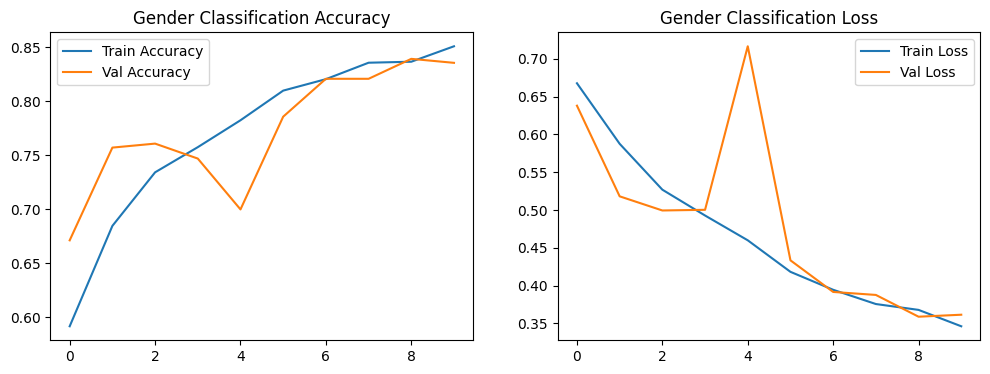

In [46]:
# 3. Hiển thị kết quả
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_gender.history['accuracy'], label='Train Accuracy')
plt.plot(history_gender.history['val_accuracy'], label='Val Accuracy')
plt.title('Gender Classification Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gender.history['loss'], label='Train Loss')
plt.plot(history_gender.history['val_loss'], label='Val Loss')
plt.title('Gender Classification Loss')
plt.legend()

plt.show()

Saving nguoi8.jpg to nguoi8 (1).jpg
Saving nguoi7.jpg to nguoi7 (1).jpg
Saving nguoi6.jpg to nguoi6 (1).jpg
Saving nguoi5.jpg to nguoi5 (1).jpg
Saving nguoi4.jpg to nguoi4 (1).jpg


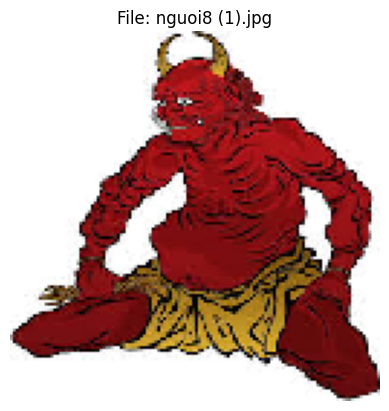

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Kết quả dự đoán: Female (95.10%)


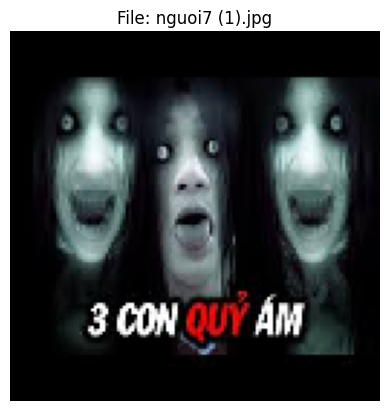

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Kết quả dự đoán: Female (90.97%)


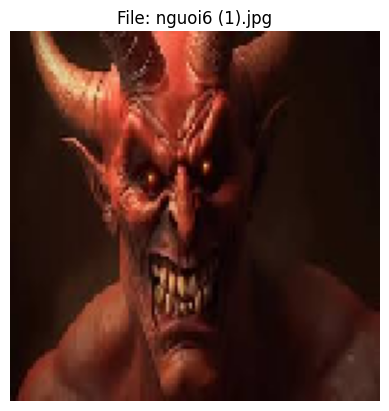

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Kết quả dự đoán: Male (65.47%)


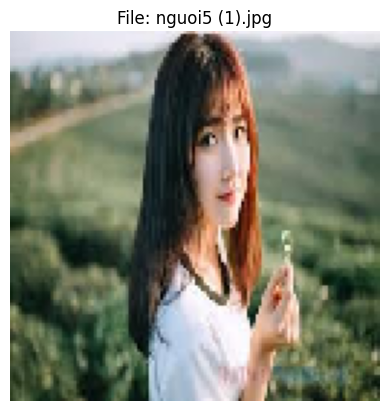

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Kết quả dự đoán: Female (94.00%)


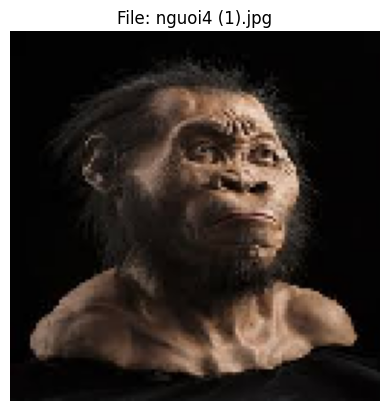

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Kết quả dự đoán: Male (53.66%)


In [50]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(128, 128))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    plt.imshow(img)
    plt.title(f"File: {fn}")
    plt.axis('off')
    plt.show()

    if 'model_gender' in globals():
        pred = model_gender.predict(x)

        result = "Male" if pred[0][0] > 0.5 else "Female"
        confidence = pred[0][0] if pred[0][0] > 0.5 else 1 - pred[0][0]
        print(f"Kết quả dự đoán: {result} ({confidence*100:.2f}%)")
    else:
        print("Lỗi: model_gender chưa được huấn luyện xong!")